In [1]:
import scipy.io
import pandas as pd
from scipy.io import loadmat 
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy.signal import butter, sosfiltfilt
import neurokit2 as nk

In [2]:
folder = r"F:\M143020071\MI"
mat_path = os.path.join(folder, "new_dataname_400_1.mat")
csv_path = os.path.join(folder, "combined_sknaMI.csv")
raw_data_folder = r"F:\M143020071\MI\raw data/"
non_MI_save_dir = r"D:\M143020071\MI\raw_data_result\iSKNA_signal\ch1\sr10000_500_3000_MI_1000pts_win20s_step2s\non_MI/"
MI_save_dir = r"D:\M143020071\MI\raw_data_result\iSKNA_signal\ch1\sr10000_500_3000_MI_1000pts_win20s_step2s\MI/"

for d in [non_MI_save_dir, MI_save_dir]:
    if not os.path.exists(d):
        os.makedirs(d)
        print(f"已建立資料夾: {d}")

data = loadmat(mat_path, squeeze_me=True)
df = pd.read_csv(csv_path)
selected_files = data['H_and_P']
selected_df = df[df['Selected'] == True]

In [3]:
print(f"從 .mat 讀到的數量: {len(selected_files)}")
print(f"從 CSV 篩選出的數量: {len(selected_df)}")
print("前 5 個選中的檔名範例:", selected_files[:5])

從 .mat 讀到的數量: 400
從 CSV 篩選出的數量: 400
前 5 個選中的檔名範例: ['0425.mat' '0427.mat' '0432.mat' '0433.mat' '0436.mat']


In [4]:
def butter_bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype='band', output='sos')
    return sos

def butter_lowpass_sos(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    sos = butter(order, normal_cutoff, btype='low', output='sos')
    return sos

def sliding_window_extract(signal, fs=10, window_sec=20, step_sec=2):
    """
    對訊號進行滑動視窗切割，並保留完整的訊號片段作為特徵。
    預期輸入 signal 為降頻後 (10Hz) 的一維陣列。
    """
    window_size = window_sec * fs  # 60 * 10 = 600 點
    step_size = step_sec * fs      # 1 * 10 = 10 點
    
    windows = []
    
    # 滑動視窗遍歷：確保最後一個視窗也是完整的 600 點
    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        window_data = signal[start:end] # 取得 600 個點
        windows.append(window_data)
        
    # 將結果轉換為 numpy 陣列，預期輸出的 shape 為 (241, 600)
    return np.array(windows)


fs = 10000 
two_min_pts = 2 * fs * 60
five_min_pts = 5 * fs * 60
seven_min_pts = 7 * fs * 60

Processing iSKNA:   0%|          | 0/400 [00:00<?, ?it/s]

(141, 200)

[產生範例圖表 - MI=0 | 檔案: 0425.mat]


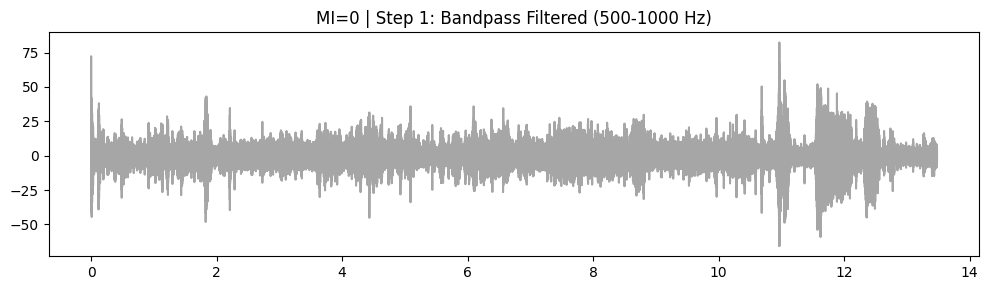

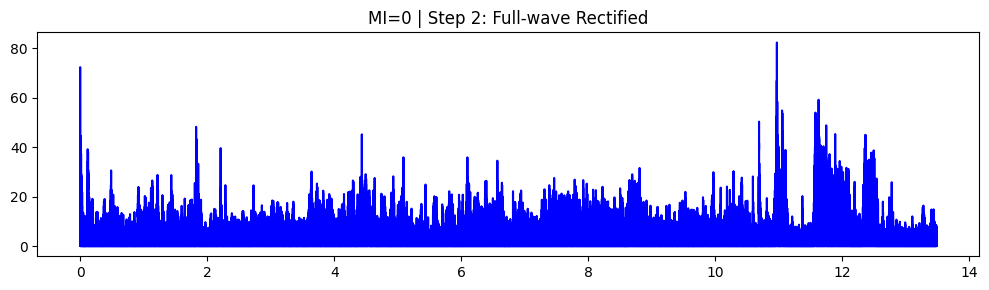

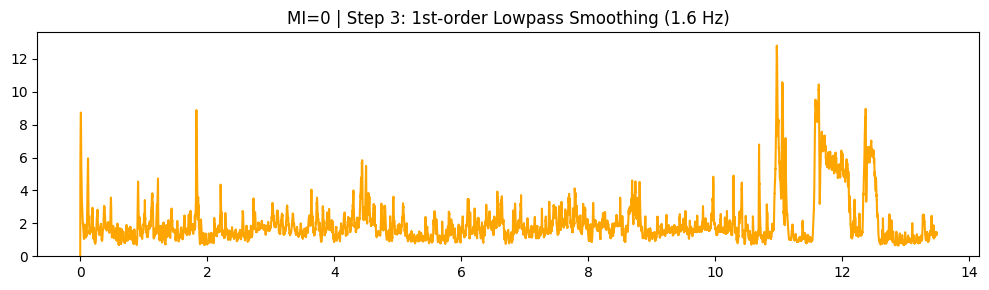

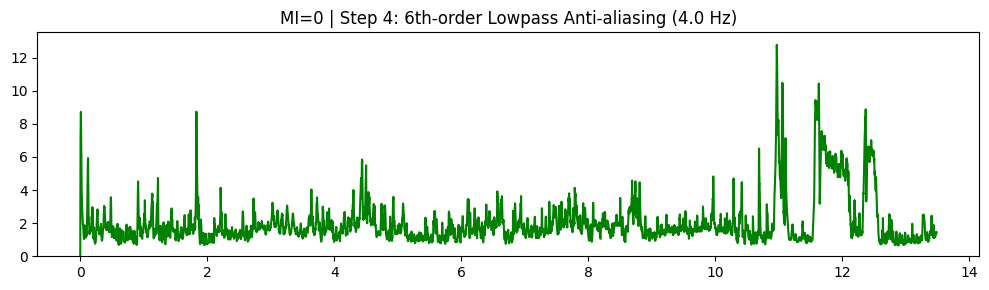

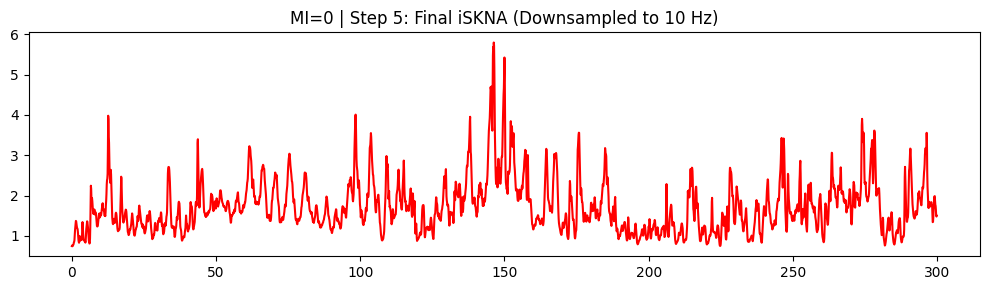

Processing iSKNA:   0%|          | 2/400 [00:06<17:45,  2.68s/it]

(141, 200)


Processing iSKNA:   1%|          | 3/400 [00:06<11:54,  1.80s/it]

(141, 200)


Processing iSKNA:   1%|          | 4/400 [00:07<09:09,  1.39s/it]

...

(141, 200)


Processing iSKNA:  50%|████▉     | 199/400 [02:32<02:31,  1.33it/s]

(141, 200)


Processing iSKNA:  50%|█████     | 200/400 [02:33<02:25,  1.38it/s]

(141, 200)
(141, 200)

[產生範例圖表 - MI=1 | 檔案: 0002.mat]


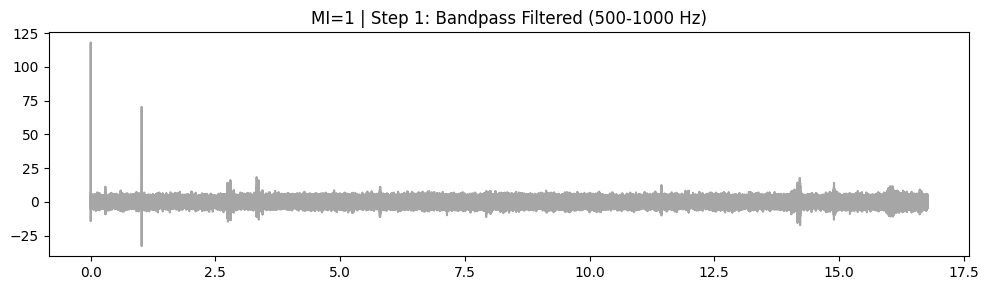

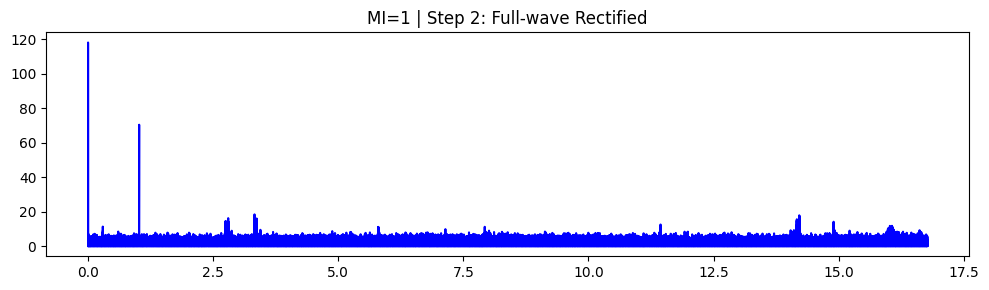

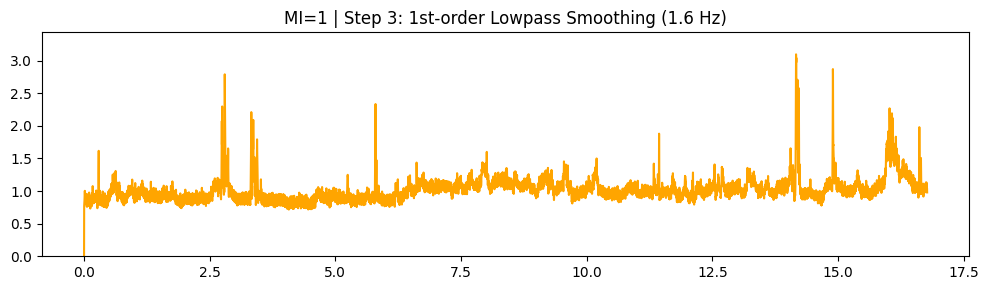

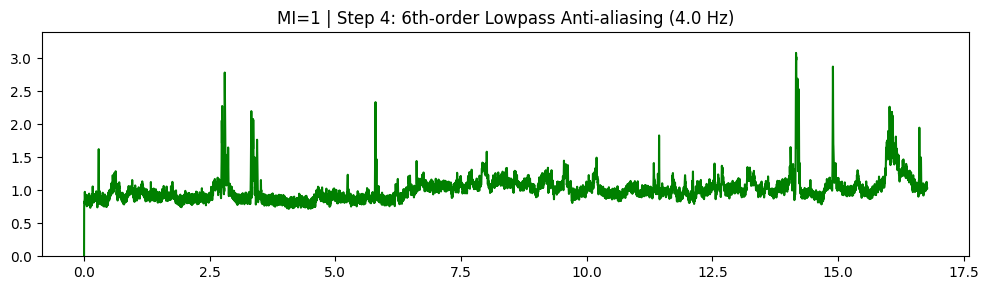

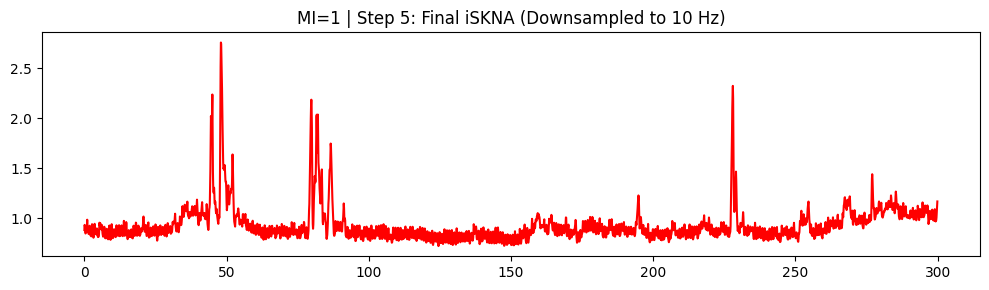

Processing iSKNA:  50%|█████     | 202/400 [02:39<05:29,  1.67s/it]

(141, 200)


Processing iSKNA:  51%|█████     | 203/400 [02:39<04:25,  1.35s/it]

(141, 200)


Processing iSKNA:  51%|█████     | 204/400 [02:40<03:39,  1.12s/it]

...

(141, 200)


Processing iSKNA: 100%|█████████▉| 399/400 [04:42<00:00,  1.50it/s]

(141, 200)


Processing iSKNA: 100%|██████████| 400/400 [04:43<00:00,  1.41it/s]

(141, 200)

所有程序完成！共成功處理並儲存 400 位受試者的 iSKNA 資料。


In [ ]:
processed_count = 0
active_df = df[df['Selected'] == True].copy()
active_df['file_name_mat'] = active_df['ID Number'].apply(lambda x: f"{str(int(x)).zfill(4)}.mat")
label_dict = pd.Series(active_df.MI.astype(int).values, index=active_df.file_name_mat).to_dict()

viz_done_0 = False  
viz_done_1 = False  

for file_name in tqdm(selected_files, desc="Processing iSKNA"):
    
    file_path = os.path.join(raw_data_folder, file_name)
    
    if not os.path.exists(file_path):
        continue
        
    try:
        # A. 讀取 .mat 並抓取 Ch1
        mat = scipy.io.loadmat(file_path, squeeze_me=True)
        signal = mat['data'][:, 0]
        
        # B. 濾波流程
        # 1. 帶通濾波 (500-3000 Hz)
        sos_bp = butter_bandpass_sos(500, 3000, fs, order=2)
        filtered_sig = sosfiltfilt(sos_bp, signal)
        
        # 2. 取絕對值 (Rectification)
        rectified_sig = np.abs(filtered_sig)
        
        # 3. 1階平滑 (1.6 Hz)
        sos_env = butter_lowpass_sos(1.6, fs, order=1)
        smoothed_env = sosfiltfilt(sos_env, rectified_sig)
        
        # 4. 6階抗混疊 (4.0 Hz)
        sos_aa = butter_lowpass_sos(4.0, fs, order=6)
        anti_aliased_sig = sosfiltfilt(sos_aa, smoothed_env)
        
        # C. 擷取時段 (2-7 分鐘)
        current_len = len(anti_aliased_sig)
        if current_len >= two_min_pts:
            if current_len < seven_min_pts:
                # 抓最後 5 分鐘
                segment = anti_aliased_sig[-five_min_pts:]
            else:
                # 抓 2-7 分鐘這區間
                segment = anti_aliased_sig[two_min_pts : seven_min_pts]
        else:
            print(f"檔案 {file_name} 長度不足 2 分鐘，跳過。")
            continue

        # D. 降採樣 (10000Hz -> 10Hz)
        downsample = 1000
        iskna_downsampled = segment.reshape(-1, 1000).mean(axis=1)

        # E. 滑動視窗
        windowed_signal = sliding_window_extract(iskna_downsampled, fs=10, window_sec=20, step_sec=2)
       

        # --- 修改處：判定此檔案是否需要畫圖 ---
        label = label_dict.get(file_name, -1) # 提前取得 MI 標籤
        
        should_plot = False
        if label == 0 and not viz_done_0:
            should_plot = True
        elif label == 1 and not viz_done_1:
            should_plot = True

        # 4. 視覺化檢查
        if should_plot:
            print(f"\n[產生範例圖表 - MI={label} | 檔案: {file_name}]")
            time_axis = np.arange(len(signal)) / fs / 60
            
            plt.figure(figsize=(10, 3))
            plt.plot(time_axis, filtered_sig, color='gray', alpha=0.7)
            plt.title(f'MI={label} | Step 1: Bandpass Filtered (500-1000 Hz)')
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(10, 3))
            plt.plot(time_axis, rectified_sig, color='blue')
            plt.title(f'MI={label} | Step 2: Full-wave Rectified')
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(10, 3))
            plt.plot(time_axis, smoothed_env, color='orange')
            plt.title(f'MI={label} | Step 3: 1st-order Lowpass Smoothing (1.6 Hz)')
            plt.ylim(bottom=0)
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(10, 3))
            plt.plot(time_axis, anti_aliased_sig, color='green')
            plt.title(f'MI={label} | Step 4: 6th-order Lowpass Anti-aliasing (4.0 Hz)')
            plt.ylim(bottom=0)
            plt.tight_layout()
            plt.show()
            
            time_axis_downsampled = np.arange(len(iskna_downsampled))/ (fs/downsample)
            plt.figure(figsize=(10, 3))
            plt.plot(time_axis_downsampled, iskna_downsampled, 'r-', markersize=3)
            plt.title(f'MI={label} | Step 5: Final iSKNA (Downsampled to 10 Hz)')
            plt.tight_layout()
            plt.show()
            
            # 標記該類別已畫過圖
            if label == 0: viz_done_0 = True
            if label == 1: viz_done_1 = True
        
        # ====== E. 存檔 (滑動視窗版本) ======
        # 產生形狀為 (241, 1) 的標籤矩陣 (每一列代表一個樣本的標籤)
        label_arr = np.full((windowed_signal.shape[0], 1), label)
        
        # 進行水平合併 (hstack)，最後 shape 會變成 (241, 601)
        # 第一欄是 Label (0 或 1)，後面的 600 欄是時間序列特徵
        final_save_data = np.concatenate([label_arr, windowed_signal], axis=1)
        
        # 依照標籤分類資料夾存檔 (保留你原本熟悉的寫法)
        if label == 0:
            target_dir = non_MI_save_dir
        elif label == 1:
            target_dir = MI_save_dir
        else:
            print(f"警告: {file_name} 找不到標籤，跳過存檔。")
            continue
            
        save_file_path = os.path.join(target_dir, file_name.replace('.mat', '.npy'))
        np.save(save_file_path, final_save_data)
        
        processed_count += 1
        
    except Exception as e:
        print(f"處理 {file_name} 時出錯: {e}")

print(f"\n所有程序完成！共成功處理並儲存 {processed_count} 位受試者的 iSKNA 資料。")

In [6]:
print(df['ID Number'].isnull().sum()) # 檢查 ID 有幾個空值
print(df['MI'].isnull().sum())        # 檢查 MI 有幾個空值
print(iskna_downsampled.shape)
print(windowed_signal.shape)

0
2
(3000,)
(141, 200)
